<a href="https://colab.research.google.com/github/Chembia/CDC26/blob/main/CDC26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [68]:
import pandas as pd

import pandas as pd

url = 'https://raw.githubusercontent.com/Chembia/CDC26/main/credit_cards_2022_2025.csv.gz'

# Pandas automatically detects and decompresses .gz files!
df = pd.read_csv(url, compression='gzip', low_memory=False)
print(f"Loaded {len(df):,} records!")

# 2. Standardize column names to match model & Gradio dashboard features
df = df.rename(
    columns={
        'Company': 'company',
        'State': 'state',
        'Issue': 'issue',
        'Product': 'product',
        'Submitted via': 'submitted_via',
        'Timely response?': 'timely_response',
        'Company response to consumer': 'company_response',
        'Date received': 'date_received',
    }
)

# 3. Format dates for EDA charts
df['date_received'] = pd.to_datetime(df['date_received'])
df['month'] = df['date_received'].dt.to_period('M')

# 4. Target feature for relief prediction model
df['got_relief'] = df['company_response'].apply(
    lambda x: 1 if 'Relief' in str(x) or 'monetary' in str(x).lower() else 0
)

print(
    f'Successfully initialized {len(df):,} records!'
)

Loaded 263,028 records!
Successfully initialized 263,028 records!


In [69]:
complaints = data.get("hits", {}).get("hits", [])

rows = [item["_source"] for item in complaints]

df = pd.DataFrame(rows)

print(df.shape)
df.head()



NameError: name 'data' is not defined

In [ ]:
last_row_df = df.tail(1)
print(last_row_df)

In [ ]:

first_row = df.iloc[0]
print(first_row)

# Data Cleaning

In [ ]:
cols = [
    "zip_code",
    "state",
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "company",
    "date_received"
]
df = df[cols]

#missing code
df["zip_code"] = df["zip_code"].astype(str).str.strip()
df["zip_code"] = np.where(
    df["zip_code"].isin(["None", "nan", "", "XX", "XXXXX"]), np.nan, df["zip_code"]
)

#missing text values
df = df.fillna("Unknown")
df

# EDA

In [ ]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 110

In [ ]:
# Make column names easier to type: "Date received" -> "date_received"
df.columns = (df.columns.str.lower()
                        .str.replace(" ", "_")
                        .str.replace("-", "_")
                        .str.replace("?", ""))
df = df.rename(columns={"company_response_to_consumer": "company_response"})

# Convert dates from text to real dates
df["date_received"] = pd.to_datetime(df["date_received"])
df["month"] = df["date_received"].dt.to_period("M").dt.to_timestamp()
df["year"] = df["date_received"].dt.year

# True/False column: did the consumer get any relief (money or a fix)?
df["got_relief"] = df["company_response"].str.contains("relief", na=False)

print(df.columns.tolist())
print("Rows:", len(df))
print("Date range:", df["date_received"].min().date(), "to", df["date_received"].max().date())
print("\nMissing values per column:")
print(df.isna().sum())

['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'submitted_via', 'date_sent_to_company', 'company_response', 'timely_response', 'complaint_id', 'year', 'month', 'got_relief']
Rows: 263028
Date range: 2022-01-01 to 2025-12-31

Missing values per column:
date_received                   0
product                         0
sub_product                     0
issue                           0
sub_issue                    1261
company_public_response    138016
company                         0
state                         865
zip_code                        0
tags                       222741
submitted_via                   0
date_sent_to_company            0
company_response                0
timely_response                 0
complaint_id                    0
year                            0
month                           0
got_relief                      0
dtype: int64


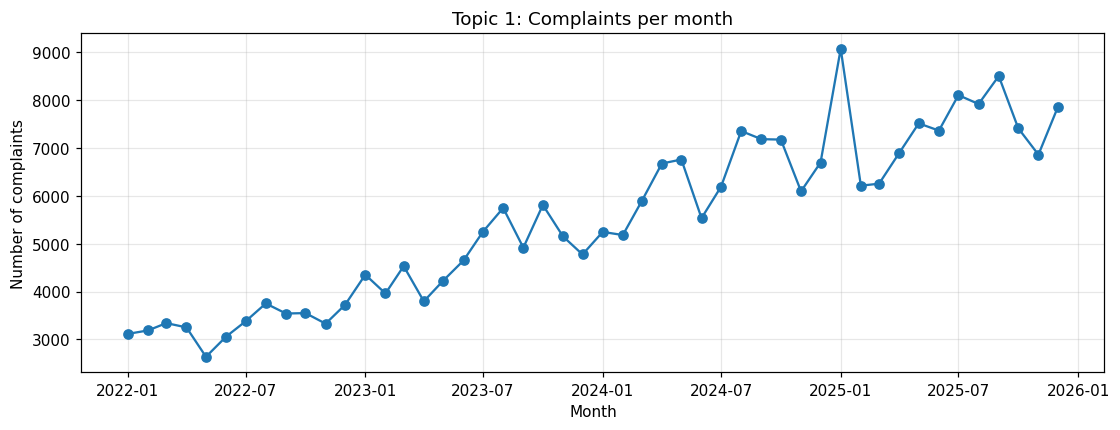

First month: 3,117   Last month: 7,859   Change: +152%
Busiest month: January 2025 (9,073 complaints)


In [ ]:
# TOPIC 1: Are complaints going up or down over time?
monthly = df.groupby("month").size()

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Topic 1: Complaints per month")
plt.xlabel("Month")
plt.ylabel("Number of complaints")
plt.grid(alpha=0.3)
plt.show()

change = (monthly.iloc[-1] - monthly.iloc[0]) / monthly.iloc[0] * 100
print(f"First month: {monthly.iloc[0]:,}   Last month: {monthly.iloc[-1]:,}   Change: {change:+.0f}%")
print("Busiest month:", monthly.idxmax().strftime("%B %Y"), f"({monthly.max():,} complaints)")

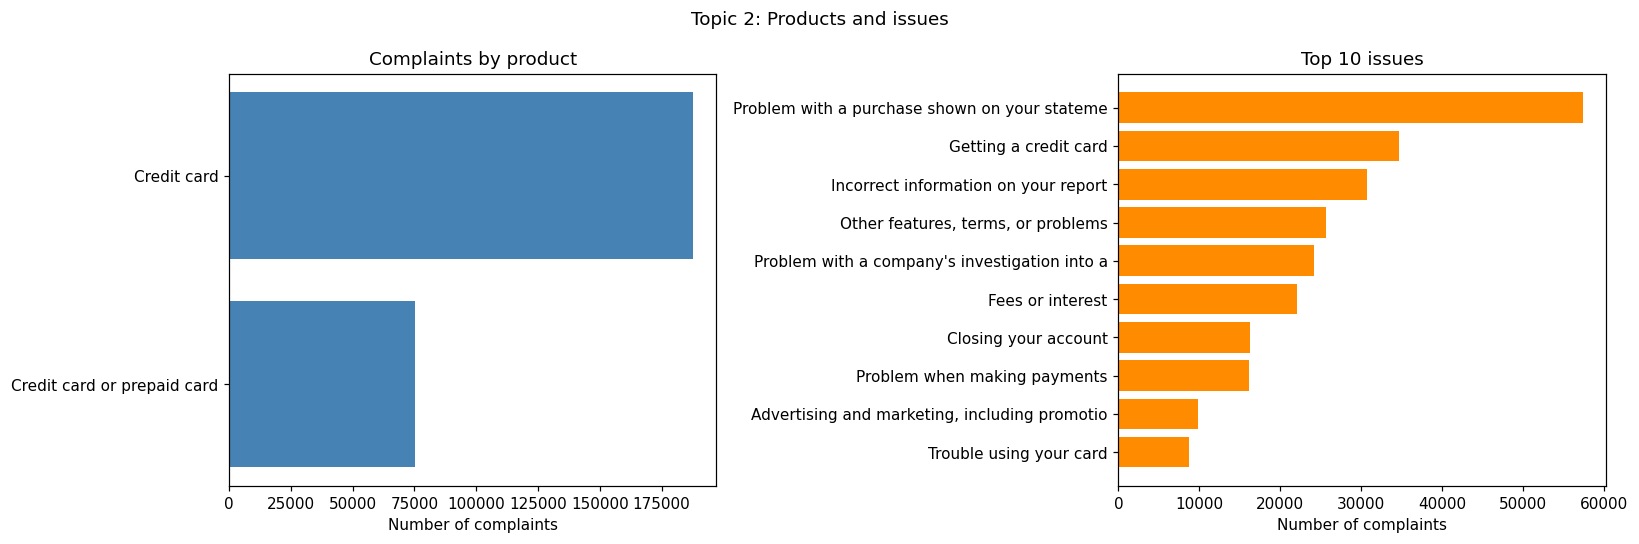

Share of complaints by product (%):
product
Credit card                    71.4
Credit card or prepaid card    28.6
Name: count, dtype: float64


In [ ]:
# TOPIC 2: Which products and issues get the most complaints?
product_counts = df["product"].value_counts()
issue_counts = df["issue"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(product_counts.index, product_counts.values, color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Complaints by product")
axes[0].set_xlabel("Number of complaints")

axes[1].barh(issue_counts.index.str[:45], issue_counts.values, color="darkorange")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 issues")
axes[1].set_xlabel("Number of complaints")

plt.suptitle("Topic 2: Products and issues")
plt.tight_layout()
plt.show()

print("Share of complaints by product (%):")
print((product_counts / len(df) * 100).round(1))

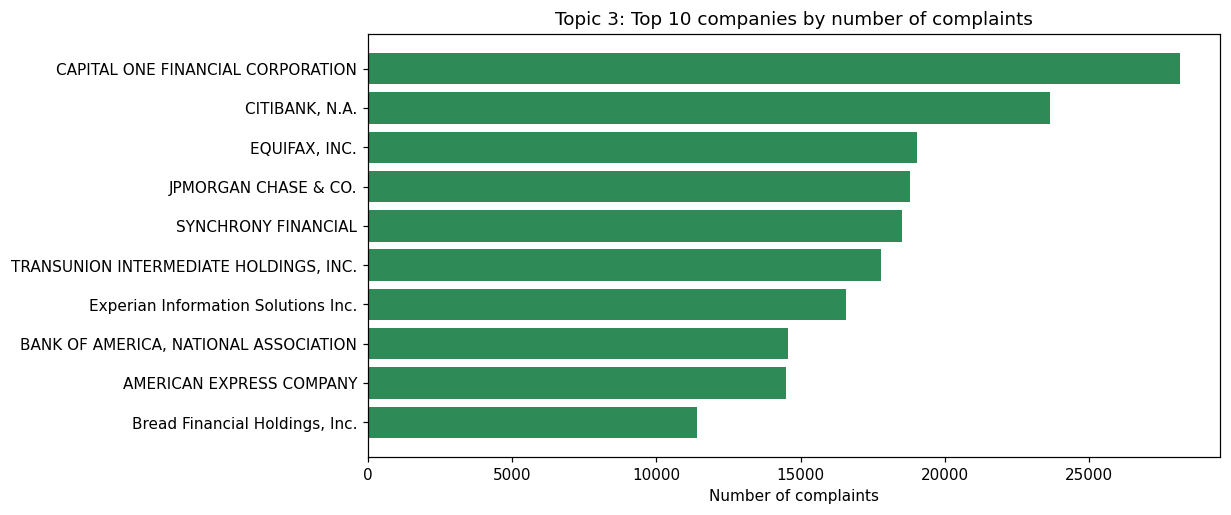

The top 10 companies (out of 864) have 70% of all complaints.
Note: big companies have more customers, so more complaints is not automatically worse.


In [ ]:
# TOPIC 3: Which companies get the most complaints?
company_counts = df["company"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(company_counts.index.str[:40], company_counts.values, color="seagreen")
plt.gca().invert_yaxis()
plt.title("Topic 3: Top 10 companies by number of complaints")
plt.xlabel("Number of complaints")
plt.show()

top10_share = company_counts.sum() / len(df) * 100
print(f"The top 10 companies (out of {df['company'].nunique():,}) have {top10_share:.0f}% of all complaints.")
print("Note: big companies have more customers, so more complaints is not automatically worse.")

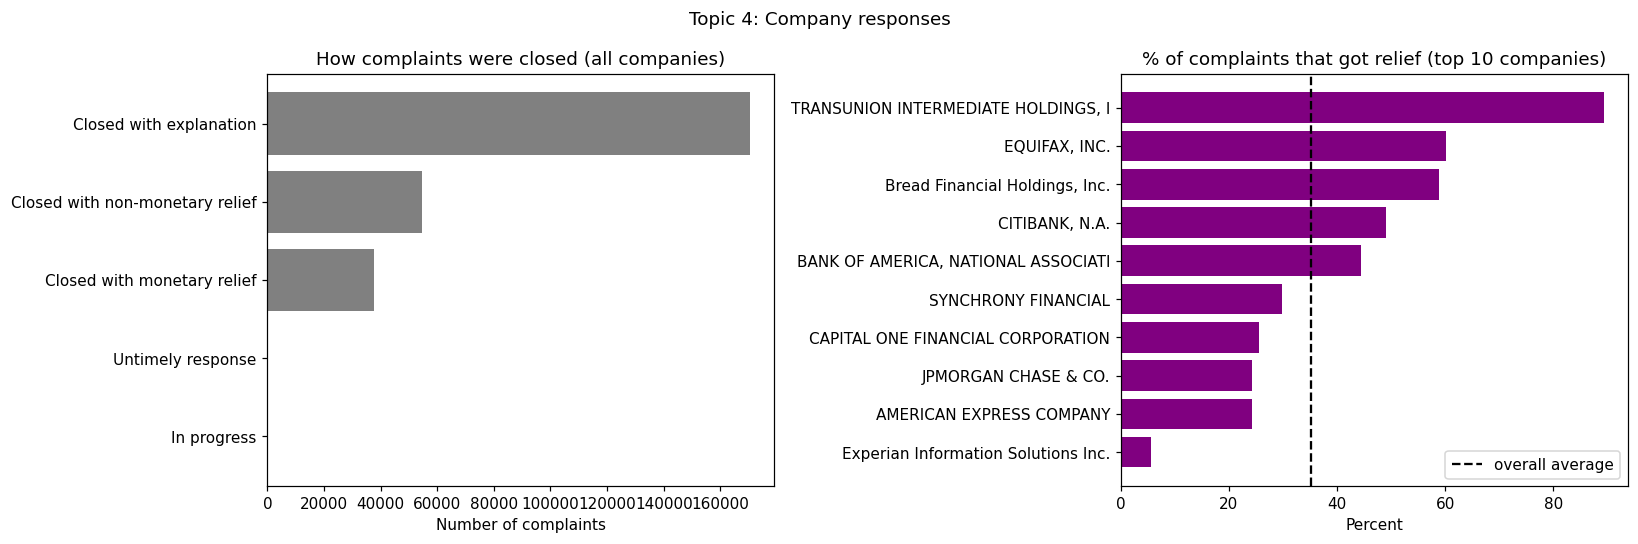

Overall relief rate: 35.1%
Timely responses: 99.5%


In [ ]:
# TOPIC 4: How do companies respond, and which companies give relief most often?
response_counts = df["company_response"].value_counts()

top_companies = df["company"].value_counts().head(10).index
relief_by_company = (df[df["company"].isin(top_companies)]
                     .groupby("company")["got_relief"].mean() * 100).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(response_counts.index, response_counts.values, color="gray")
axes[0].invert_yaxis()
axes[0].set_title("How complaints were closed (all companies)")
axes[0].set_xlabel("Number of complaints")

axes[1].barh(relief_by_company.index.str[:35], relief_by_company.values, color="purple")
axes[1].axvline(df["got_relief"].mean() * 100, color="black", linestyle="--", label="overall average")
axes[1].set_title("% of complaints that got relief (top 10 companies)")
axes[1].set_xlabel("Percent")
axes[1].legend()

plt.suptitle("Topic 4: Company responses")
plt.tight_layout()
plt.show()

print(f"Overall relief rate: {df['got_relief'].mean() * 100:.1f}%")
print(f"Timely responses: {(df['timely_response'] == 'Yes').mean() * 100:.1f}%")

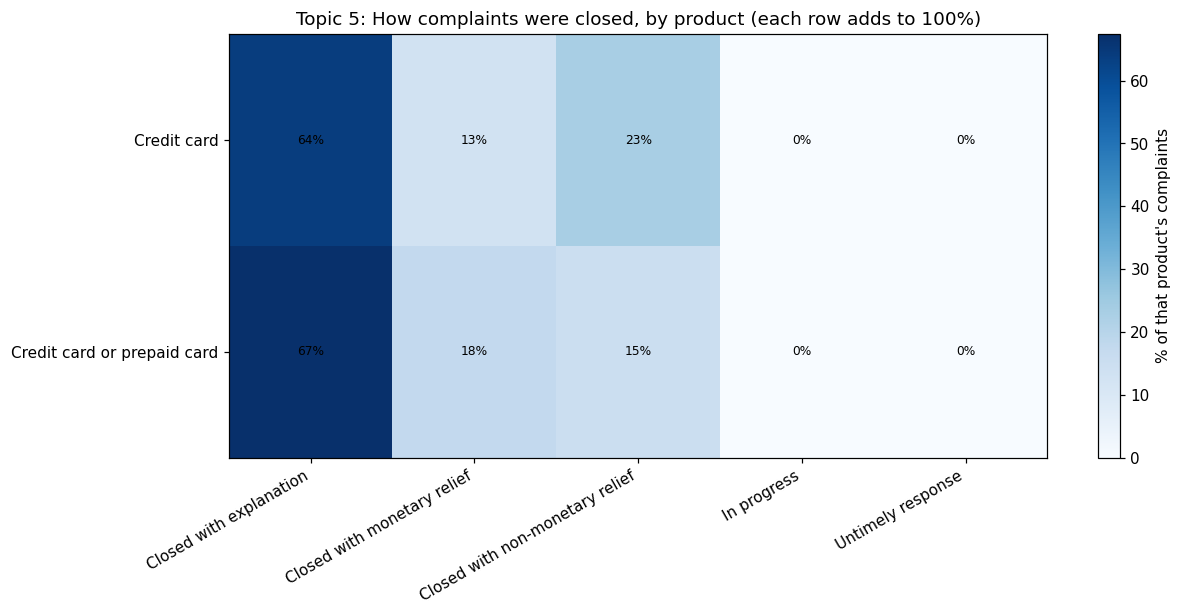

Relief rate by product (%):
product
Credit card                    36.1
Credit card or prepaid card    32.5
Name: got_relief, dtype: float64


In [ ]:
# TOPIC 5: Is the product related to the outcome? (heatmap of product vs. response)
table = pd.crosstab(df["product"], df["company_response"], normalize="index") * 100

plt.figure(figsize=(12, 5))
plt.imshow(table.values, cmap="Blues", aspect="auto")
plt.colorbar(label="% of that product's complaints")
plt.xticks(range(len(table.columns)), table.columns, rotation=30, ha="right")
plt.yticks(range(len(table.index)), table.index.str[:40])

# write the number inside each square
for i in range(len(table.index)):
    for j in range(len(table.columns)):
        plt.text(j, i, f"{table.values[i, j]:.0f}%", ha="center", va="center", fontsize=8)

plt.title("Topic 5: How complaints were closed, by product (each row adds to 100%)")
plt.show()

relief_by_product = (df.groupby("product")["got_relief"].mean() * 100).sort_values(ascending=False)
print("Relief rate by product (%):")
print(relief_by_product.round(1))

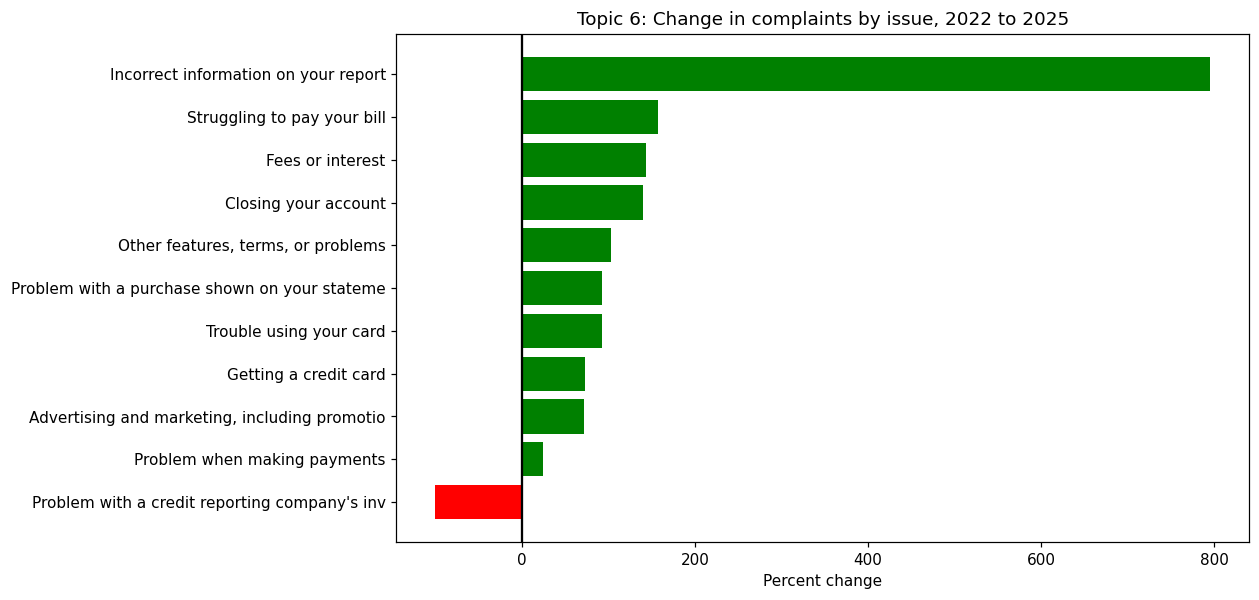

year                                                 2022   2025  pct_change
issue                                                                       
Problem with a credit reporting company's inves...    587      0      -100.0
Problem when making payments                         3674   4596        25.1
Advertising and marketing, including promotiona...   1802   3105        72.3
Getting a credit card                                6234  10805        73.3
Trouble using your card                              1567   3020        92.7
Problem with a purchase shown on your statement     10262  19810        93.0
Other features, terms, or problems                   4142   8416       103.2
Closing your account                                 2593   6224       140.0
Fees or interest                                     3214   7836       143.8
Struggling to pay your bill                           478   1233       157.9
Incorrect information on your report                 1534  13735       795.4

In [ ]:
# TOPIC 6: Which issues are growing or shrinking the fastest?
first_year = df["year"].min()
last_year = df["year"].max()

top_issues = df["issue"].value_counts().head(12).index
issue_year = pd.crosstab(df["issue"], df["year"]).loc[top_issues]
issue_year["pct_change"] = (issue_year[last_year] - issue_year[first_year]) / issue_year[first_year] * 100
issue_year = issue_year.sort_values("pct_change")

colors = ["red" if x < 0 else "green" for x in issue_year["pct_change"]]

plt.figure(figsize=(10, 6))
plt.barh(issue_year.index.str[:45], issue_year["pct_change"], color=colors)
plt.axvline(0, color="black")
plt.title(f"Topic 6: Change in complaints by issue, {first_year} to {last_year}")
plt.xlabel("Percent change")
plt.show()

print(issue_year[[first_year, last_year, "pct_change"]].round(1))

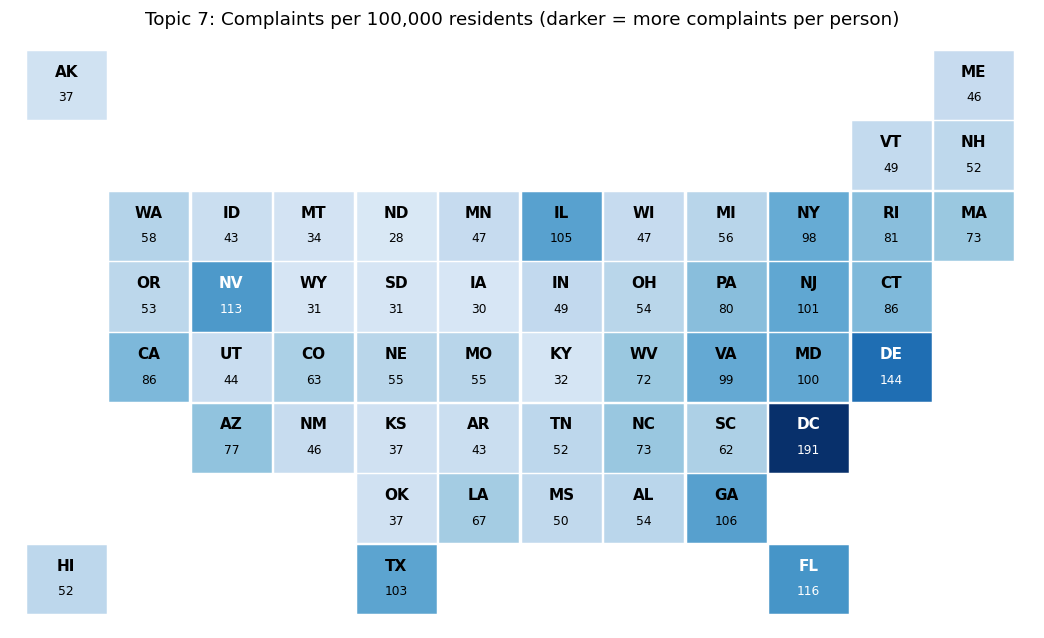

Highest per person:
 DC    190.6
DE    144.5
FL    116.4
NV    112.6
GA    106.3
dtype: float64

Lowest per person:
 KY    32.0
WY    31.4
SD    31.2
IA    29.7
ND    27.6
dtype: float64


In [ ]:
# TOPIC 7: Where are complaints coming from? (complaints per 100,000 people, as a tile map)
# 2020 Census population for each state
population = {
    "AL": 5024279, "AK": 733391, "AZ": 7151502, "AR": 3011524, "CA": 39538223, "CO": 5773714,
    "CT": 3605944, "DE": 989948, "DC": 689545, "FL": 21538187, "GA": 10711908, "HI": 1455271,
    "ID": 1839106, "IL": 12812508, "IN": 6785528, "IA": 3190369, "KS": 2937880, "KY": 4505836,
    "LA": 4657757, "ME": 1362359, "MD": 6177224, "MA": 7029917, "MI": 10077331, "MN": 5706494,
    "MS": 2961279, "MO": 6154913, "MT": 1084225, "NE": 1961504, "NV": 3104614, "NH": 1377529,
    "NJ": 9288994, "NM": 2117522, "NY": 20201249, "NC": 10439388, "ND": 779094, "OH": 11799448,
    "OK": 3959353, "OR": 4237256, "PA": 13002700, "RI": 1097379, "SC": 5118425, "SD": 886667,
    "TN": 6910840, "TX": 29145505, "UT": 3271616, "VT": 643077, "VA": 8631393, "WA": 7705281,
    "WV": 1793716, "WI": 5893718, "WY": 576851,
}

# (row, column) position of each state on a simple grid map of the US
grid = {
    "AK": (0, 0), "ME": (0, 11),
    "VT": (1, 10), "NH": (1, 11),
    "WA": (2, 1), "ID": (2, 2), "MT": (2, 3), "ND": (2, 4), "MN": (2, 5), "IL": (2, 6),
    "WI": (2, 7), "MI": (2, 8), "NY": (2, 9), "RI": (2, 10), "MA": (2, 11),
    "OR": (3, 1), "NV": (3, 2), "WY": (3, 3), "SD": (3, 4), "IA": (3, 5), "IN": (3, 6),
    "OH": (3, 7), "PA": (3, 8), "NJ": (3, 9), "CT": (3, 10),
    "CA": (4, 1), "UT": (4, 2), "CO": (4, 3), "NE": (4, 4), "MO": (4, 5), "KY": (4, 6),
    "WV": (4, 7), "VA": (4, 8), "MD": (4, 9), "DE": (4, 10),
    "AZ": (5, 2), "NM": (5, 3), "KS": (5, 4), "AR": (5, 5), "TN": (5, 6), "NC": (5, 7),
    "SC": (5, 8), "DC": (5, 9),
    "OK": (6, 4), "LA": (6, 5), "MS": (6, 6), "AL": (6, 7), "GA": (6, 8),
    "HI": (7, 0), "TX": (7, 4), "FL": (7, 9),
}

state_counts = df["state"].value_counts()
per_100k = {}
for state in population:
    per_100k[state] = state_counts.get(state, 0) / population[state] * 100000
per_100k = pd.Series(per_100k).sort_values(ascending=False)

# draw the tile map
fig, ax = plt.subplots(figsize=(12, 7))
cmap = plt.cm.Blues
low, high = per_100k.min(), per_100k.max()
for state, (row, col) in grid.items():
    value = per_100k[state]
    shade = (value - low) / (high - low)          # 0 = lowest state, 1 = highest state
    ax.add_patch(plt.Rectangle((col, -row), 0.95, 0.95, color=cmap(0.15 + 0.85 * shade)))
    text_color = "white" if shade > 0.5 else "black"
    ax.text(col + 0.47, -row + 0.6, state, ha="center", fontsize=10, weight="bold", color=text_color)
    ax.text(col + 0.47, -row + 0.25, f"{value:.0f}", ha="center", fontsize=8, color=text_color)
ax.set_xlim(-0.2, 12.2)
ax.set_ylim(-7.2, 1.2)
ax.axis("off")
ax.set_title("Topic 7: Complaints per 100,000 residents (darker = more complaints per person)")
plt.show()

print("Highest per person:\n", per_100k.head(5).round(1))
print("\nLowest per person:\n", per_100k.tail(5).round(1))

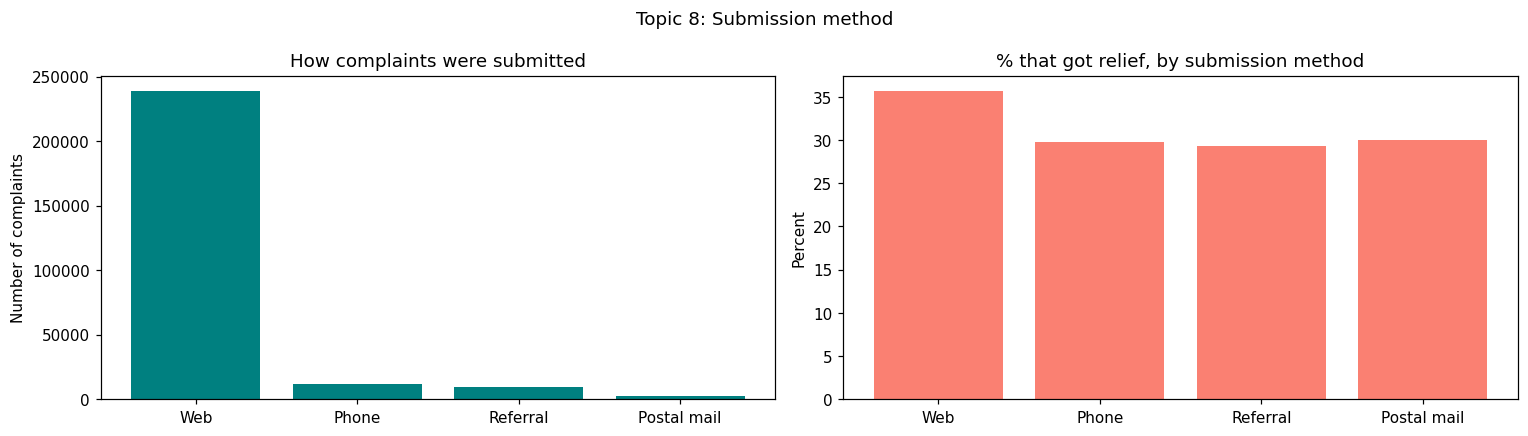

submitted_via
Web            90.8
Phone           4.5
Referral        3.8
Postal mail     1.0
Name: count, dtype: float64


In [ ]:
# TOPIC 8: Does how people submit their complaint relate to the outcome?
channel_counts = df["submitted_via"].value_counts()
relief_by_channel = df.groupby("submitted_via")["got_relief"].mean() * 100
relief_by_channel = relief_by_channel[channel_counts.index]   # same order as the counts

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(channel_counts.index, channel_counts.values, color="teal")
axes[0].set_title("How complaints were submitted")
axes[0].set_ylabel("Number of complaints")

axes[1].bar(relief_by_channel.index, relief_by_channel.values, color="salmon")
axes[1].set_title("% that got relief, by submission method")
axes[1].set_ylabel("Percent")

plt.suptitle("Topic 8: Submission method")
plt.tight_layout()
plt.show()

print((channel_counts / len(df) * 100).round(1))

In [ ]:
# SUMMARY: the strongest patterns to consider for the main analysis
print("EDA SUMMARY")
print("-" * 60)
print(f"1. Volume: {len(df):,} complaints; changed {change:+.0f}% from first to last month.")
print(f"2. Biggest product: {product_counts.index[0]} ({product_counts.iloc[0] / len(df) * 100:.0f}% of complaints).")
print(f"   Biggest issue: {issue_counts.index[0]}.")
print(f"3. Most complaints: {company_counts.index[0]}. Top 10 companies = {top10_share:.0f}% of complaints.")
print(f"4. Highest relief rate (top 10 companies): {relief_by_company.index[-1]} ({relief_by_company.iloc[-1]:.0f}%)")
print(f"   Lowest relief rate (top 10 companies):  {relief_by_company.index[0]} ({relief_by_company.iloc[0]:.0f}%)")
print(f"5. Product with most relief: {relief_by_product.index[0]} ({relief_by_product.iloc[0]:.0f}%)")
print(f"6. Fastest-growing issue: {issue_year.index[-1]} ({issue_year['pct_change'].iloc[-1]:+.0f}%)")
print(f"   Fastest-shrinking issue: {issue_year.index[0]} ({issue_year['pct_change'].iloc[0]:+.0f}%)")
print(f"7. Most complaints per person: {per_100k.index[0]} ({per_100k.iloc[0]:.0f} per 100k)")
print(f"8. Most common submission method: {channel_counts.index[0]} ({channel_counts.iloc[0] / len(df) * 100:.0f}%)")

EDA SUMMARY
------------------------------------------------------------
1. Volume: 263,028 complaints; changed +152% from first to last month.
2. Biggest product: Credit card (71% of complaints).
   Biggest issue: Problem with a purchase shown on your statement.
3. Most complaints: CAPITAL ONE FINANCIAL CORPORATION. Top 10 companies = 70% of complaints.
4. Highest relief rate (top 10 companies): TRANSUNION INTERMEDIATE HOLDINGS, INC. (89%)
   Lowest relief rate (top 10 companies):  Experian Information Solutions Inc. (6%)
5. Product with most relief: Credit card (36%)
6. Fastest-growing issue: Problem with a company's investigation into an existing problem (+inf%)
   Fastest-shrinking issue: Problem with a credit reporting company's investigation into an existing problem (-100%)
7. Most complaints per person: DC (191 per 100k)
8. Most common submission method: Web (91%)


# Issue Concentration Heatmap by Top States

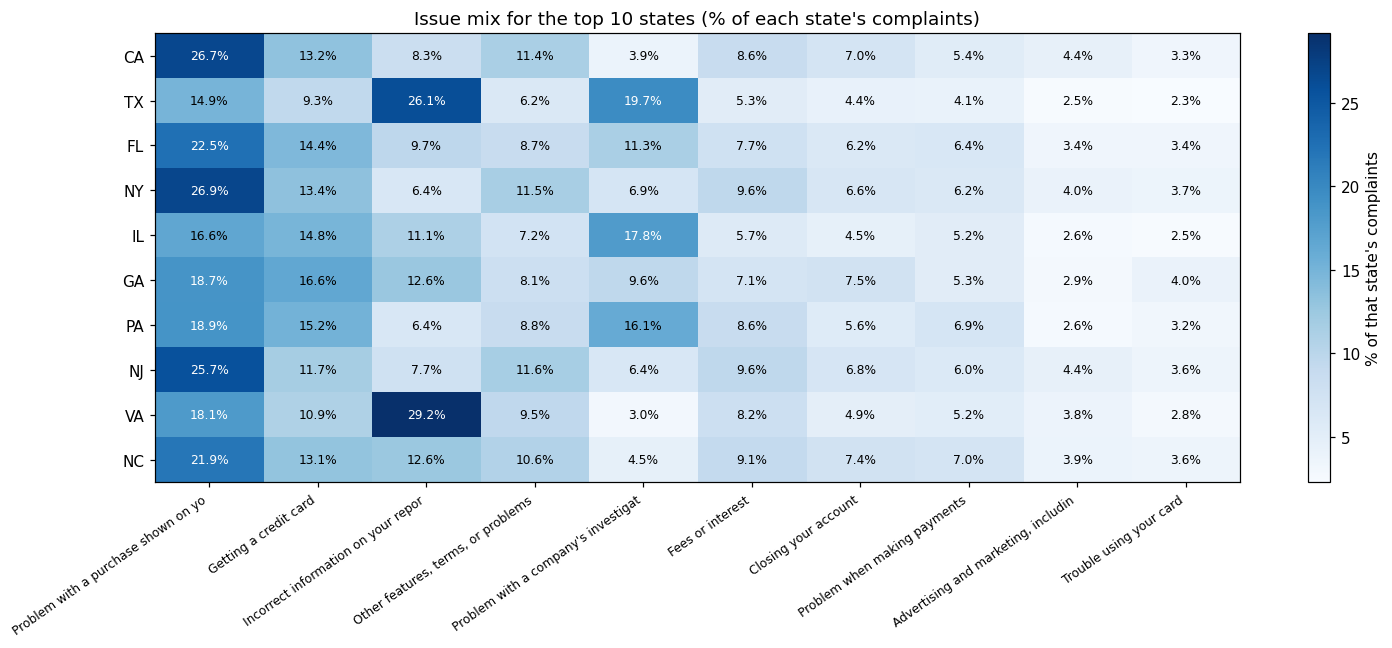

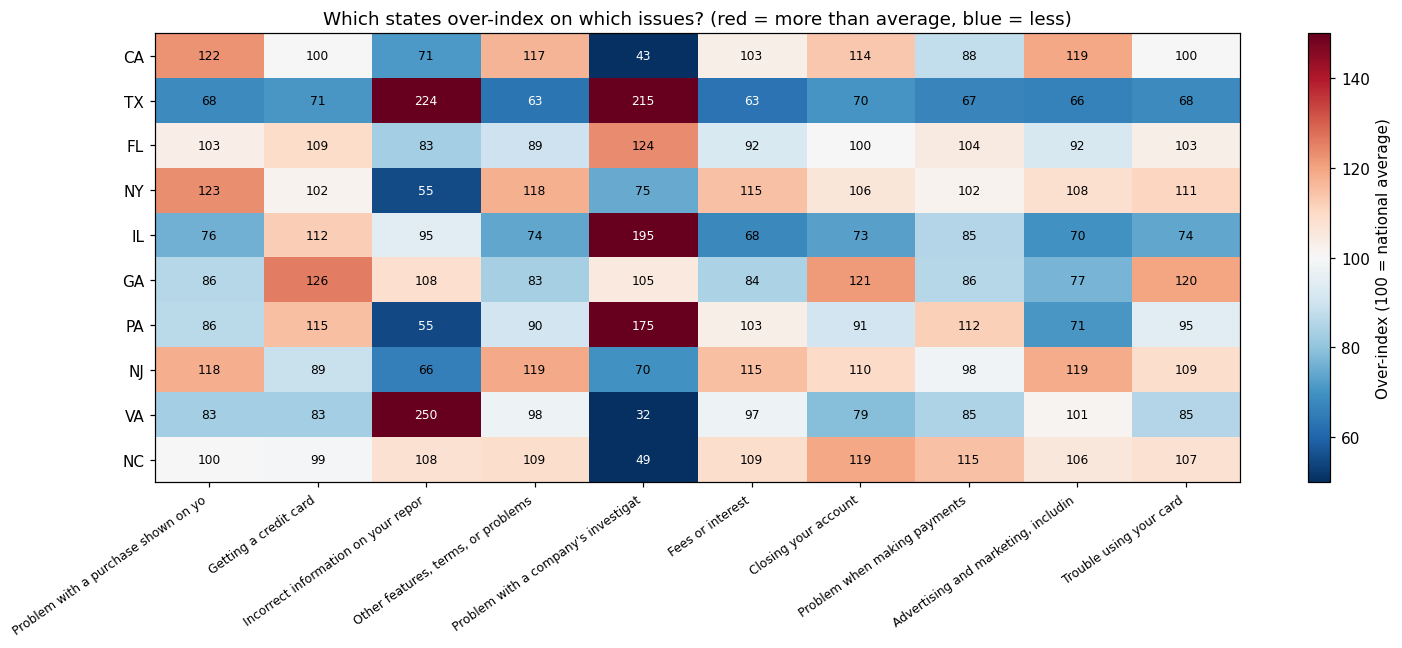

Biggest OVER-index (state complains about this more than average):
state                                                           issue  over_index  state_pct  complaints
   VA                            Incorrect information on your report       250.3       29.2        2495
   TX                            Incorrect information on your report       224.1       26.1        7879
   TX Problem with a company's investigation into an existing problem       214.7       19.7        5936
   IL Problem with a company's investigation into an existing problem       194.6       17.8        2407
   PA Problem with a company's investigation into an existing problem       175.3       16.1        1682
   GA                                           Getting a credit card       125.8       16.6        1885
   FL Problem with a company's investigation into an existing problem       123.6       11.3        2842
   NY                 Problem with a purchase shown on your statement       123.2       26.9 

In [ ]:
# STATES vs ISSUES: Do the busiest states complain about the same things?

# Step 1: find the top 10 states and top 10 issues
top_states = df["state"].value_counts().head(10).index
top_issues = df["issue"].value_counts().head(10).index

# Step 2: count complaints for each state + issue combo
state_data = df[df["state"].isin(top_states)]
counts = pd.crosstab(state_data["state"], state_data["issue"])
counts = counts.reindex(index=top_states, columns=top_issues, fill_value=0)

# Step 3: turn counts into percentages of each state's total complaints
# (so big states like FL and TX don't look darker just because they're bigger)
state_totals = df["state"].value_counts()[top_states]
state_pct = counts.div(state_totals, axis=0) * 100

# Step 4: national average % for each issue (the "normal" amount)
national_pct = df["issue"].value_counts(normalize=True)[top_issues] * 100

# Step 5: over-index score = state % / national % * 100
# 100 = same as national average, 130 = 30% MORE than average, 70 = 30% LESS
over_index = state_pct / national_pct * 100

short_issues = [name[:35] for name in top_issues]   # shorten long issue names for the labels

# ----- Heatmap 1: what % of each state's complaints are each issue -----
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(state_pct.values, cmap="Blues", aspect="auto")
fig.colorbar(im, label="% of that state's complaints")

ax.set_xticks(range(len(top_issues)))
ax.set_xticklabels(short_issues, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(top_states)))
ax.set_yticklabels(top_states)

for i in range(len(top_states)):
    for j in range(len(top_issues)):
        value = state_pct.values[i, j]
        color = "white" if value > state_pct.values.max() * 0.6 else "black"
        ax.text(j, i, f"{value:.1f}%", ha="center", va="center", fontsize=8, color=color)

ax.set_title("Issue mix for the top 10 states (% of each state's complaints)")
plt.tight_layout()
plt.savefig("state_issue_percent.pdf")
plt.show()

# ----- Heatmap 2: which states over-index on which issues -----
# colors go from 50 (dark blue) to 150 (dark red), with white at 100
# anything above 150 or below 50 just shows the darkest color
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(over_index.values, cmap="RdBu_r", aspect="auto", vmin=50, vmax=150)
fig.colorbar(im, label="Over-index (100 = national average)")

ax.set_xticks(range(len(top_issues)))
ax.set_xticklabels(short_issues, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(top_states)))
ax.set_yticklabels(top_states)

for i in range(len(top_states)):
    for j in range(len(top_issues)):
        value = over_index.values[i, j]
        color = "white" if value > 135 or value < 65 else "black"
        ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=8, color=color)

ax.set_title("Which states over-index on which issues? (red = more than average, blue = less)")
plt.tight_layout()
plt.savefig("state_issue_over_index.pdf")
plt.show()

# Step 6: list the biggest over- and under-index combos
pairs = over_index.stack().reset_index()
pairs.columns = ["state", "issue", "over_index"]
pairs["state_pct"] = state_pct.stack().values
pairs["complaints"] = counts.stack().values
pairs = pairs[pairs["complaints"] >= 30]            # skip tiny numbers that could be random

print("Biggest OVER-index (state complains about this more than average):")
print(pairs.sort_values("over_index", ascending=False).head(8).round(1).to_string(index=False))
print("\nBiggest UNDER-index (state complains about this less than average):")
print(pairs.sort_values("over_index").head(5).round(1).to_string(index=False))

# Step 7: one number to answer "same profile or not?"
# average distance of each state's over-index from 100 (0 = identical to the nation)
difference = (over_index - 100).abs().mean(axis=1).sort_values(ascending=False)
print("\nHow different is each state's issue mix from the national average? (0 = identical)")
print(difference.round(1))

States found: 51
Total complaints per year in dataset:
year
2023     2132
2024    13204
2025    13697
dtype: int64

National growth 2023 -> 2025: +542%
year   2023  2024  2025  growth_pct  surge_ratio  per_100k_2025
state                                                          
VA       56   577  1825      3158.9          5.1           21.1
DE       11    73   143      1200.0          2.0           14.4
TX      293  3848  3627      1137.9          1.9           12.4
MD       39   315   383       882.1          1.5            6.2
LA       18   189   155       761.1          1.3            3.3
MA       19   195   148       678.9          1.2            2.1
NC       66   357   492       645.5          1.2            4.7
AL       23   225   168       630.4          1.1            3.3
CA      172  1412  1077       526.2          1.0            2.7
CT       18    92   102       466.7          0.9            2.8

8 of 32 states grew within ±25% of the national rate.


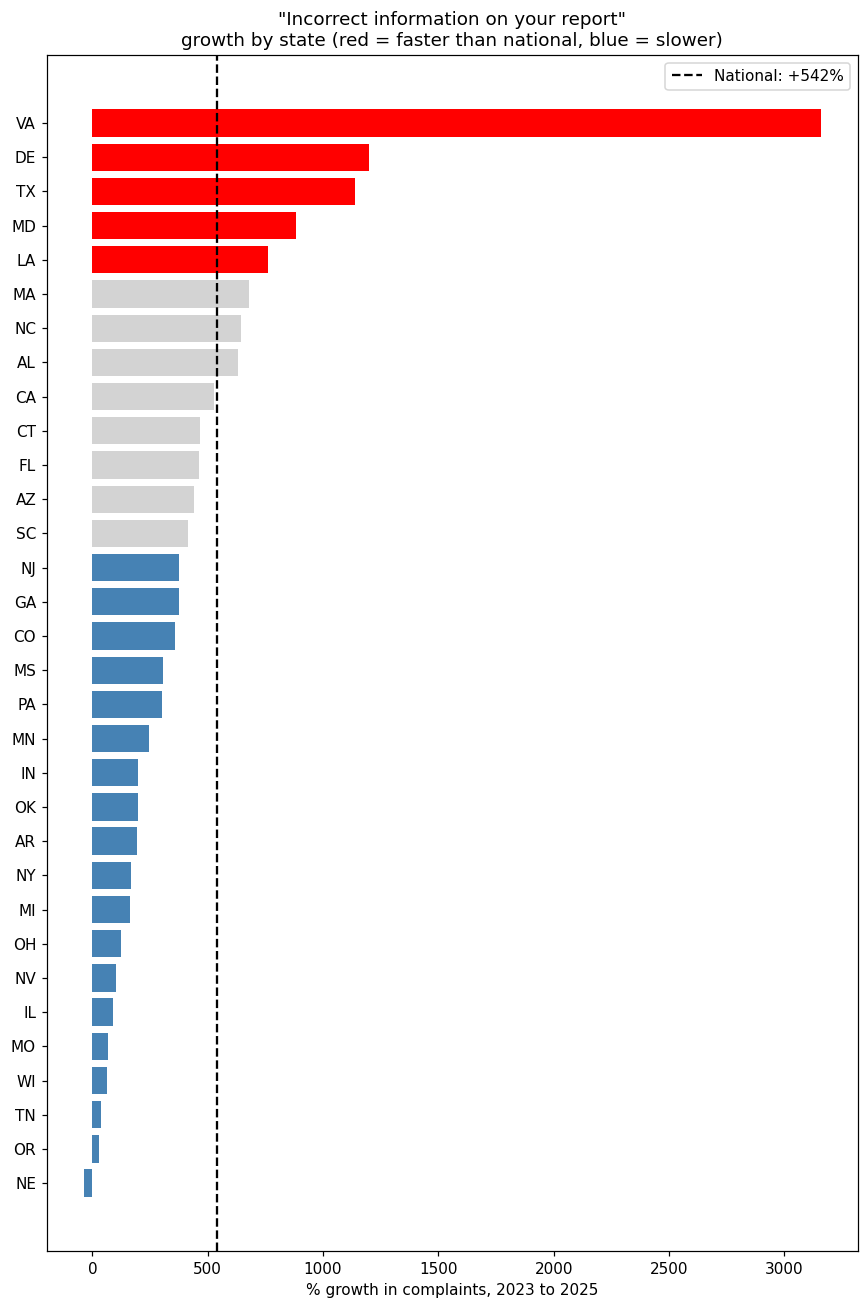

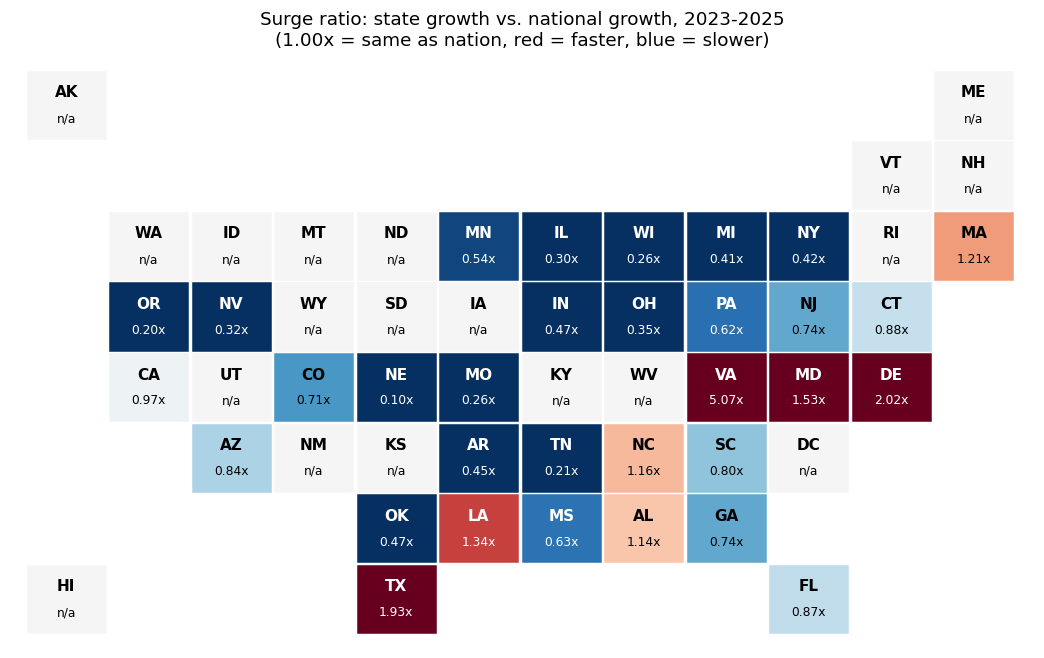

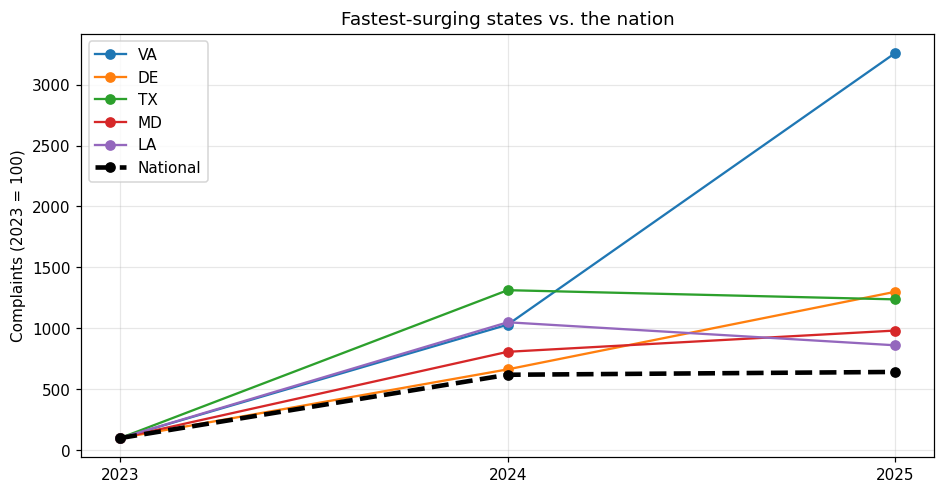

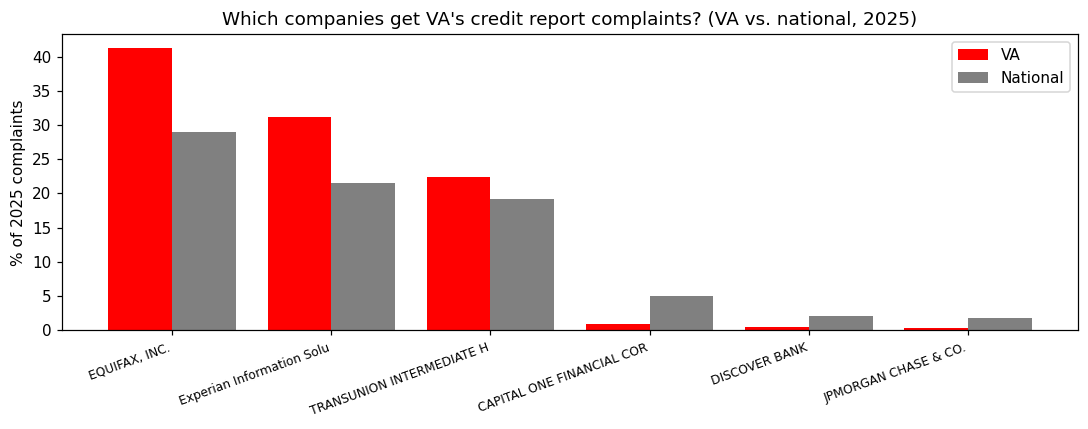

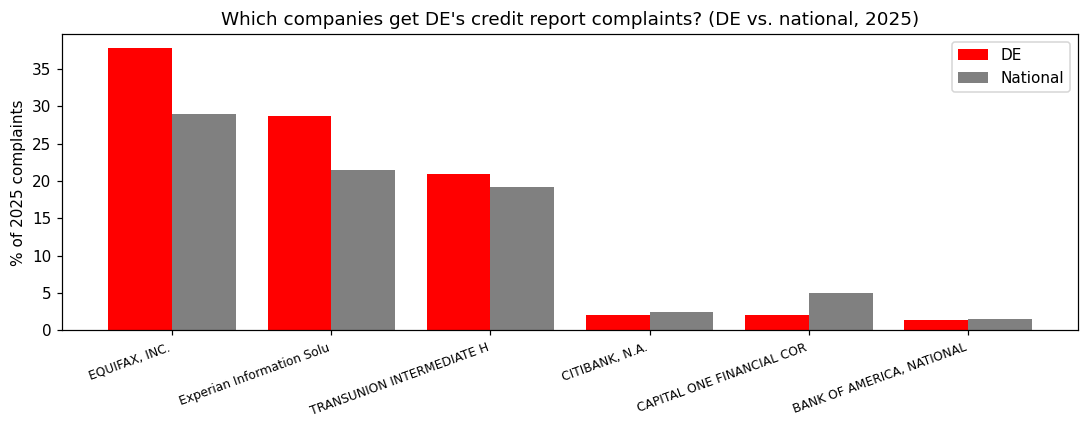

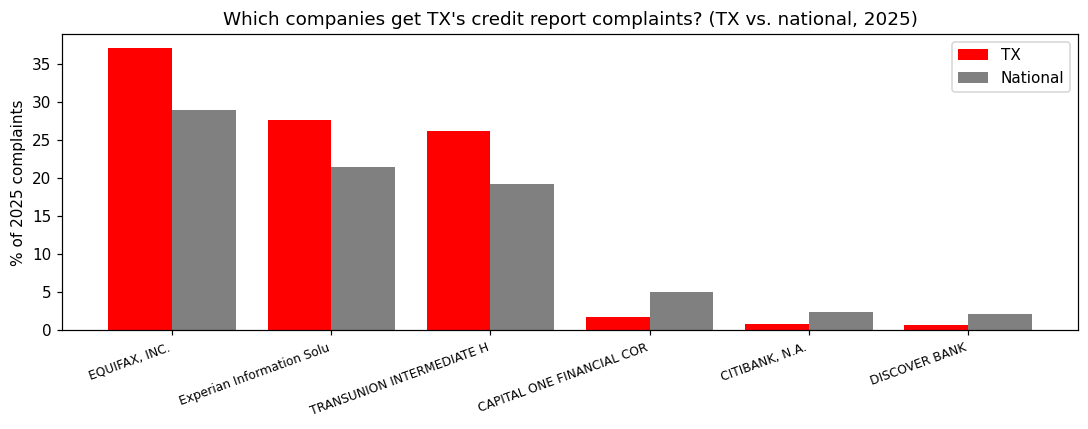


Analysis complete! Processed entirely using local `df`.


In [63]:
# ============================================================================
# CREDIT REPORT ERRORS: Is "Incorrect information on your report" spiking
# everywhere in the US, or only in certain states? (2023 -> 2025)
# Using loaded `df` instead of blocked API calls.
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2020 Census population for each state
population = {
    "AL": 5024279,
    "AK": 733391,
    "AZ": 7151502,
    "AR": 3011524,
    "CA": 39538223,
    "CO": 5773714,
    "CT": 3605944,
    "DE": 989948,
    "DC": 689545,
    "FL": 21538187,
    "GA": 10711908,
    "HI": 1455271,
    "ID": 1839106,
    "IL": 12812508,
    "IN": 6785528,
    "IA": 3190369,
    "KS": 2937880,
    "KY": 4505836,
    "LA": 4657757,
    "ME": 1362359,
    "MD": 6177224,
    "MA": 7029917,
    "MI": 10077331,
    "MN": 5706494,
    "MS": 2961279,
    "MO": 6154913,
    "MT": 1084225,
    "NE": 1961504,
    "NV": 3104614,
    "NH": 1377529,
    "NJ": 9288994,
    "NM": 2117522,
    "NY": 20201249,
    "NC": 10439388,
    "ND": 779094,
    "OH": 11799448,
    "OK": 3959353,
    "OR": 4237256,
    "PA": 13002700,
    "RI": 1097379,
    "SC": 5118425,
    "SD": 886667,
    "TN": 6910840,
    "TX": 29145505,
    "UT": 3271616,
    "VT": 643077,
    "VA": 8631393,
    "WA": 7705281,
    "WV": 1793716,
    "WI": 5893718,
    "WY": 576851,
}

# (row, column) position of each state on a grid map
grid = {
    "AK": (0, 0),
    "ME": (0, 11),
    "VT": (1, 10),
    "NH": (1, 11),
    "WA": (2, 1),
    "ID": (2, 2),
    "MT": (2, 3),
    "ND": (2, 4),
    "MN": (2, 5),
    "IL": (2, 6),
    "WI": (2, 7),
    "MI": (2, 8),
    "NY": (2, 9),
    "RI": (2, 10),
    "MA": (2, 11),
    "OR": (3, 1),
    "NV": (3, 2),
    "WY": (3, 3),
    "SD": (3, 4),
    "IA": (3, 5),
    "IN": (3, 6),
    "OH": (3, 7),
    "PA": (3, 8),
    "NJ": (3, 9),
    "CT": (3, 10),
    "CA": (4, 1),
    "UT": (4, 2),
    "CO": (4, 3),
    "NE": (4, 4),
    "MO": (4, 5),
    "KY": (4, 6),
    "WV": (4, 7),
    "VA": (4, 8),
    "MD": (4, 9),
    "DE": (4, 10),
    "AZ": (5, 2),
    "NM": (5, 3),
    "KS": (5, 4),
    "AR": (5, 5),
    "TN": (5, 6),
    "NC": (5, 7),
    "SC": (5, 8),
    "DC": (5, 9),
    "OK": (6, 4),
    "LA": (6, 5),
    "MS": (6, 6),
    "AL": (6, 7),
    "GA": (6, 8),
    "HI": (7, 0),
    "TX": (7, 4),
    "FL": (7, 9),
}

ISSUE = "Incorrect information on your report"
YEARS = [2023, 2024, 2025]

# Ensure date_received is datetime and create year column if not present
if "year" not in df.columns:
  df["date_received"] = pd.to_datetime(df["date_received"])
  df["year"] = df["date_received"].dt.year

# Filter loaded df for the specific issue
issue_mask = df["issue"].str.contains(ISSUE, case=False, na=False)
df_issue = df[issue_mask].copy()

# 1. Group complaints by state and year from local DataFrame
state_year = (
    df_issue.groupby(["state", "year"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=YEARS, fill_value=0)
)
state_year = state_year[
    state_year.index.isin(population.keys())
]  # keep 50 states + DC

print("States found:", len(state_year))
print("Total complaints per year in dataset:")
print(state_year.sum())

# 2. Compute Growth statistics from 2023 to 2025
MIN_2023 = 10  # adjusted threshold for filtered subset

national_2023 = state_year[2023].sum()
national_2025 = state_year[2025].sum()

if national_2023 > 0:
  national_growth = (national_2025 - national_2023) / national_2023 * 100
  national_multiple = national_2025 / national_2023
else:
  national_growth = 0
  national_multiple = 1

growth = state_year[state_year[2023] >= MIN_2023].copy()
growth["growth_pct"] = (growth[2025] - growth[2023]) / growth[2023] * 100
growth["surge_ratio"] = (growth[2025] / growth[2023]) / (
    national_multiple if national_multiple != 0 else 1
)
growth["per_100k_2025"] = growth[2025] / growth.index.map(population) * 100000
growth = growth.sort_values("growth_pct", ascending=False)

print(f"\nNational growth 2023 -> 2025: {national_growth:+,.0f}%")
print(
    growth[[2023, 2024, 2025, "growth_pct", "surge_ratio", "per_100k_2025"]]
    .round(1)
    .head(10)
)

similar = growth[
    (growth["surge_ratio"] >= 0.75) & (growth["surge_ratio"] <= 1.25)
]
print(
    f"\n{len(similar)} of {len(growth)} states grew within ±25% of the national"
    " rate."
)

# ----- Chart 1: Growth % for every state -----
bar_colors = []
for ratio in growth["surge_ratio"]:
  if ratio > 1.25:
    bar_colors.append("red")
  elif ratio < 0.75:
    bar_colors.append("steelblue")
  else:
    bar_colors.append("lightgray")

plt.figure(figsize=(8, 12))
plt.barh(growth.index, growth["growth_pct"], color=bar_colors)
plt.axvline(
    national_growth,
    color="black",
    linestyle="--",
    label=f"National: {national_growth:+,.0f}%",
)
plt.gca().invert_yaxis()
plt.xlabel("% growth in complaints, 2023 to 2025")
plt.title(
    f'"{ISSUE}"\ngrowth by state (red = faster than national, blue = slower)'
)
plt.legend()
plt.tight_layout()
plt.savefig("credit_report_growth_by_state.pdf")
plt.show()

# ----- Chart 2: Tile Map -----
fig, ax = plt.subplots(figsize=(12, 7))
cmap = plt.cm.RdBu_r
for state, (row, col) in grid.items():
  if state in growth.index:
    ratio = growth.loc[state, "surge_ratio"]
    shade = min(max((ratio - 0.5) / 1.0, 0.0), 1.0)
    label = f"{ratio:.2f}x"
  else:
    shade = None
    label = "n/a"
  color = "whitesmoke" if shade is None else cmap(shade)
  ax.add_patch(plt.Rectangle((col, -row), 0.95, 0.95, color=color))
  text_color = (
      "white"
      if shade is not None and (shade > 0.8 or shade < 0.2)
      else "black"
  )
  ax.text(
      col + 0.47,
      -row + 0.6,
      state,
      ha="center",
      fontsize=10,
      weight="bold",
      color=text_color,
  )
  ax.text(
      col + 0.47,
      -row + 0.25,
      label,
      ha="center",
      fontsize=8,
      color=text_color,
  )
ax.set_xlim(-0.2, 12.2)
ax.set_ylim(-7.2, 1.2)
ax.axis("off")
ax.set_title(
    "Surge ratio: state growth vs. national growth, 2023-2025\n(1.00x = same"
    " as nation, red = faster, blue = slower)"
)
plt.savefig("credit_report_surge_map.pdf")
plt.show()

# ----- Chart 3: Top 5 Trend -----
top5 = growth.head(5).index
plt.figure(figsize=(10, 5))
for state in top5:
  indexed = (
      growth.loc[state, YEARS]
      / (growth.loc[state, 2023] if growth.loc[state, 2023] > 0 else 1)
      * 100
  )
  plt.plot([str(y) for y in YEARS], indexed.values, marker="o", label=state)

national_indexed = (
    state_year[YEARS].sum() / (national_2023 if national_2023 > 0 else 1) * 100
)
plt.plot(
    [str(y) for y in YEARS],
    national_indexed.values,
    marker="o",
    color="black",
    linewidth=3,
    linestyle="--",
    label="National",
)
plt.ylabel("Complaints (2023 = 100)")
plt.title("Fastest-surging states vs. the nation")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("credit_report_top5_trend.pdf")
plt.show()

# ----- Chart 4: Company breakdown by surging states -----
df_2025 = df_issue[df_issue["year"] == 2025]
national_companies = df_2025["company"].value_counts()
national_share = national_companies / national_companies.sum() * 100

for state in growth.head(3).index:
  state_companies = df_2025[df_2025["state"] == state]["company"].value_counts()
  if len(state_companies) > 0:
    state_share = state_companies / state_companies.sum() * 100
    top_company_names = state_share.head(6).index

    compare = pd.DataFrame({
        state: state_share[top_company_names],
        "National": national_share.reindex(top_company_names).fillna(0),
    })

    positions = np.arange(len(top_company_names))
    plt.figure(figsize=(10, 4))
    plt.bar(
        positions - 0.2, compare[state], width=0.4, label=state, color="red"
    )
    plt.bar(
        positions + 0.2,
        compare["National"],
        width=0.4,
        label="National",
        color="gray",
    )
    plt.xticks(
        positions,
        [name[:25] for name in top_company_names],
        rotation=20,
        ha="right",
        fontsize=8,
    )
    plt.ylabel("% of 2025 complaints")
    plt.title(
        f"Which companies get {state}'s credit report complaints? ({state} vs."
        " national, 2025)"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"credit_report_companies_{state}.pdf")
    plt.show()

print(f"\nAnalysis complete! Processed entirely using local `df`.")

# Discrepancy Analysis: DC & Delaware vs. Other States


--- TOP ISSUE COMPARISON (%) ---
                                                 DC & Delaware  Rest of US
issue                                                                     
Problem with a purchase shown on your statement           19.4        21.8
Getting a credit card                                     12.5        13.2
Incorrect information on your report                      12.4        11.7
Other features, terms, or problems                        12.0         9.7
Fees or interest                                           8.4         8.4


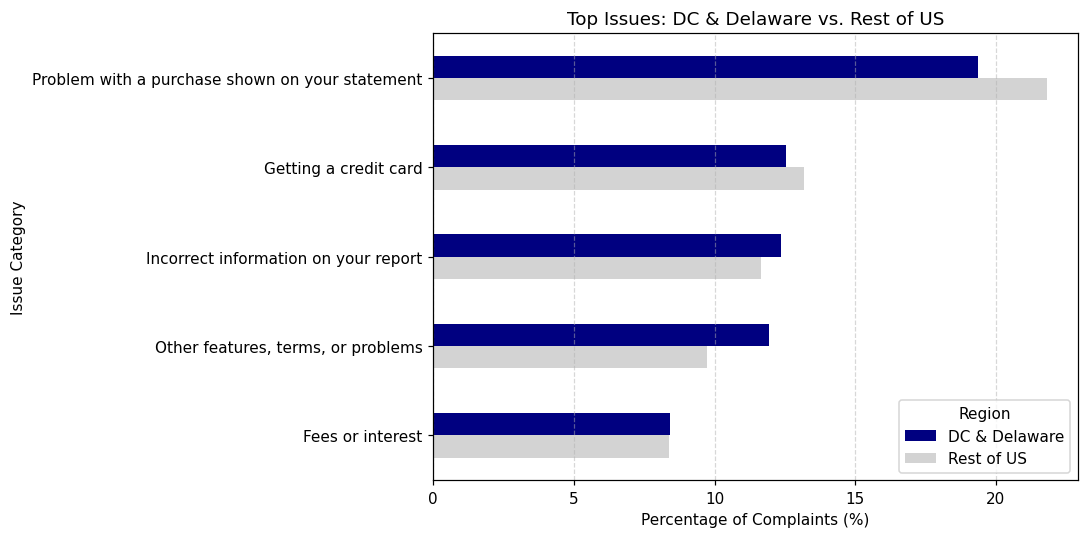


--- TOP COMPANIES COMPLAINED ABOUT IN DC & DELAWARE ---
company
CAPITAL ONE FINANCIAL CORPORATION    358
CITIBANK, N.A.                       273
JPMORGAN CHASE & CO.                 212
AMERICAN EXPRESS COMPANY             182
SYNCHRONY FINANCIAL                  180
Name: count, dtype: int64


In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. SETUP & SEPARATE DC/DE FROM NATIONAL BASELINE
# Using 'df_dc_de_analysis' to avoid variable conflicts
# ---------------------------------------------------------
df_dc_de_analysis = df.copy()

# Flag rows as either 'DC/DE' or 'Rest of US'
is_dc_de = df_dc_de_analysis["state"].isin(["DC", "DE"])

# Calculate percentage breakdown of top issues in DC/DE
dc_de_issues = (
    df_dc_de_analysis[is_dc_de]["issue"].value_counts(normalize=True).head(5)
    * 100
)

# Calculate percentage breakdown of top issues in the Rest of US
national_issues = (
    df_dc_de_analysis[~is_dc_de]["issue"]
    .value_counts(normalize=True)[dc_de_issues.index]
    * 100
)

# Combine into a single comparison table
issue_comparison = pd.DataFrame(
    {"DC & Delaware": dc_de_issues, "Rest of US": national_issues}
)

print("--- TOP ISSUE COMPARISON (%) ---")
print(issue_comparison.round(1))

# ---------------------------------------------------------
# 2. PLOT SIDE-BY-SIDE BAR CHART
# ---------------------------------------------------------
ax = issue_comparison.plot(
    kind="barh", figsize=(10, 5), color=["navy", "lightgray"]
)

plt.title("Top Issues: DC & Delaware vs. Rest of US")
plt.xlabel("Percentage of Complaints (%)")
plt.ylabel("Issue Category")
plt.gca().invert_yaxis()  # Put top issue at the top
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend(title="Region")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. COMPANY PROFILES IN DC/DE (Corporate Hub Analysis)
# ---------------------------------------------------------
print("\n--- TOP COMPANIES COMPLAINED ABOUT IN DC & DELAWARE ---")
top_dc_de_companies = (
    df_dc_de_analysis[is_dc_de]["company"].value_counts().head(5)
)
print(top_dc_de_companies)

# EDA Dashboard

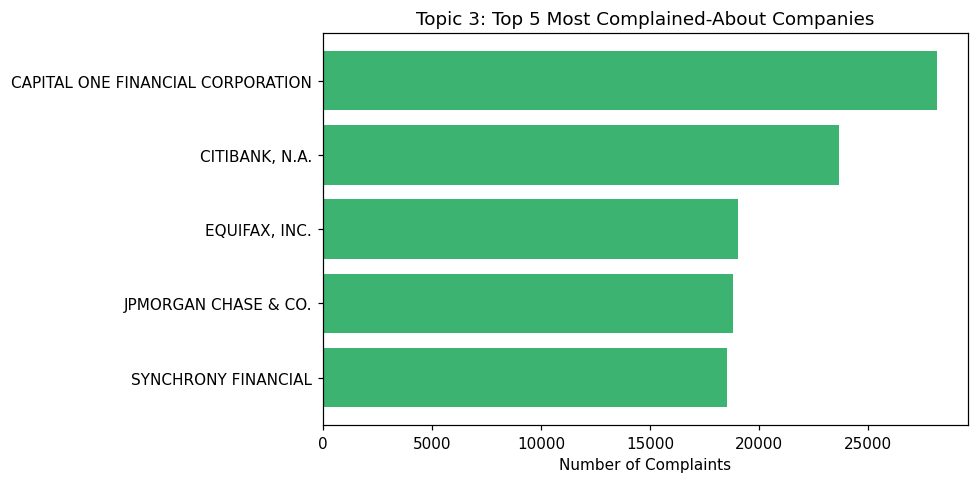

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. SETUP DATASET & COLAB INTERACTIVE DROPDOWN
# Select the topic on the right side of the cell!
# ---------------------------------------------------------
df_dashboard = df.copy()

# @title 📊 Select EDA Topic to Explore { run: "auto" }
selected_topic = '3. Top Companies'  # @param ["1. Monthly Volume Trend", "2. Top Complaint Issues", "3. Top Companies", "4. Company Response Types", "5. Overall Relief Rate", "6. Reporting Inaccuracy Surge", "7. Top States by Volume", "8. Submission Channels"]

plt.figure(figsize=(9, 4.5))

# ---------------------------------------------------------
# 2. DYNAMICALLY DISPLAY SELECTED CHART
# ---------------------------------------------------------
if selected_topic == '1. Monthly Volume Trend':
  monthly = df_dashboard.groupby('month').size()
  plt.plot(
      monthly.index.astype(str),
      monthly.values,
      marker='o',
      color='steelblue',
      linewidth=2.5,
  )
  plt.title('Topic 1: Monthly Complaint Volume (2022-2024)', fontsize=12)
  plt.ylabel('Number of Complaints')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', linestyle='--', alpha=0.5)

elif selected_topic == '2. Top Complaint Issues':
  top_issues = df_dashboard['issue'].value_counts().head(5)
  plt.barh(top_issues.index, top_issues.values, color='coral')
  plt.title('Topic 2: Top 5 Most Frequent Issues', fontsize=12)
  plt.xlabel('Number of Complaints')
  plt.gca().invert_yaxis()

elif selected_topic == '3. Top Companies':
  top_companies = df_dashboard['company'].value_counts().head(5)
  plt.barh(top_companies.index, top_companies.values, color='mediumseagreen')
  plt.title('Topic 3: Top 5 Most Complained-About Companies', fontsize=12)
  plt.xlabel('Number of Complaints')
  plt.gca().invert_yaxis()

elif selected_topic == '4. Company Response Types':
  responses = df_dashboard['company_response'].value_counts().head(4)
  clean_labels = responses.index.str.replace('Closed with ', '')
  plt.bar(clean_labels, responses.values, color='mediumpurple')
  plt.title('Topic 4: Distribution of Company Response Outcomes', fontsize=12)
  plt.ylabel('Number of Complaints')
  plt.xticks(rotation=25, ha='right')

elif selected_topic == '5. Overall Relief Rate':
  relief_pct = df_dashboard['got_relief'].value_counts(normalize=True) * 100
  plt.pie(
      relief_pct,
      labels=['No Relief', 'Got Relief'],
      autopct='%1.1f%%',
      colors=['#d3d3d3', '#2ecc71'],
      startangle=90,
      explode=(0, 0.08),
  )
  plt.title('Topic 5: Overall Proportion of Relief Granted', fontsize=12)

elif selected_topic == '6. Reporting Inaccuracy Surge':
  surge_data = (
      df_dashboard[
          df_dashboard['issue'] == 'Incorrect information on your report'
      ]
      .groupby('year')
      .size()
  )
  plt.bar(surge_data.index.astype(str), surge_data.values, color='crimson')
  plt.title(
      'Topic 6: Yearly Growth of "Incorrect Information" Issues', fontsize=12
  )
  plt.ylabel('Number of Complaints')

elif selected_topic == '7. Top States by Volume':
  states = df_dashboard['state'].value_counts().head(8)
  plt.bar(states.index, states.values, color='teal')
  plt.title('Topic 7: Top 8 States by Total Complaint Volume', fontsize=12)
  plt.ylabel('Number of Complaints')

elif selected_topic == '8. Submission Channels':
  channels = df_dashboard['submitted_via'].value_counts().head(4)
  plt.bar(channels.index, channels.values, color='gray')
  plt.title('Topic 8: How Complaints Were Submitted', fontsize=12)
  plt.ylabel('Number of Complaints')

# ---------------------------------------------------------
# 3. DISPLAY CLEAN PLOT
# ---------------------------------------------------------
plt.tight_layout()
plt.show()

# Final Dashboard

Fetching helper scripts and HHI dependencies from GitHub...
1. Loading HHI data

Data range:
2011-12 to 2026-09

Number of observations:
178

Columns:
['Month', 'HHI', 'total_complaints']

2. Checking missing values
HHI                 0
total_complaints    0
dtype: int64

3. Train / Test split

Training:
2011-12 to 2023-09
Training observations: 142

Test:
2023-10 to 2026-09
Test observations: 36

4. Testing all forecasting models

Testing: Naive

Testing: Drift

Testing: ARIMA(1,0,0)

Testing: ARIMA(1,0,1)

Testing: ARIMA(1,1,0)

Testing: ETS

5. Test-set model comparison
       Model        MAE       RMSE      MAPE
ARIMA(1,0,1)  36.565068  50.015539  5.741615
ARIMA(1,1,0)  40.103885  60.269555  6.164502
       Naive  40.857250  61.245177  6.279595
         ETS 109.694760 129.472911 17.595193
       Drift 123.251894 148.314020 19.777251
ARIMA(1,0,0) 131.181616 149.504269 22.327044

BEST MODEL ON TEST SET

Best model: ARIMA(1,0,1)
Test MAE: 36.5651
Test RMSE: 50.0155
Test MAPE: 5.7416

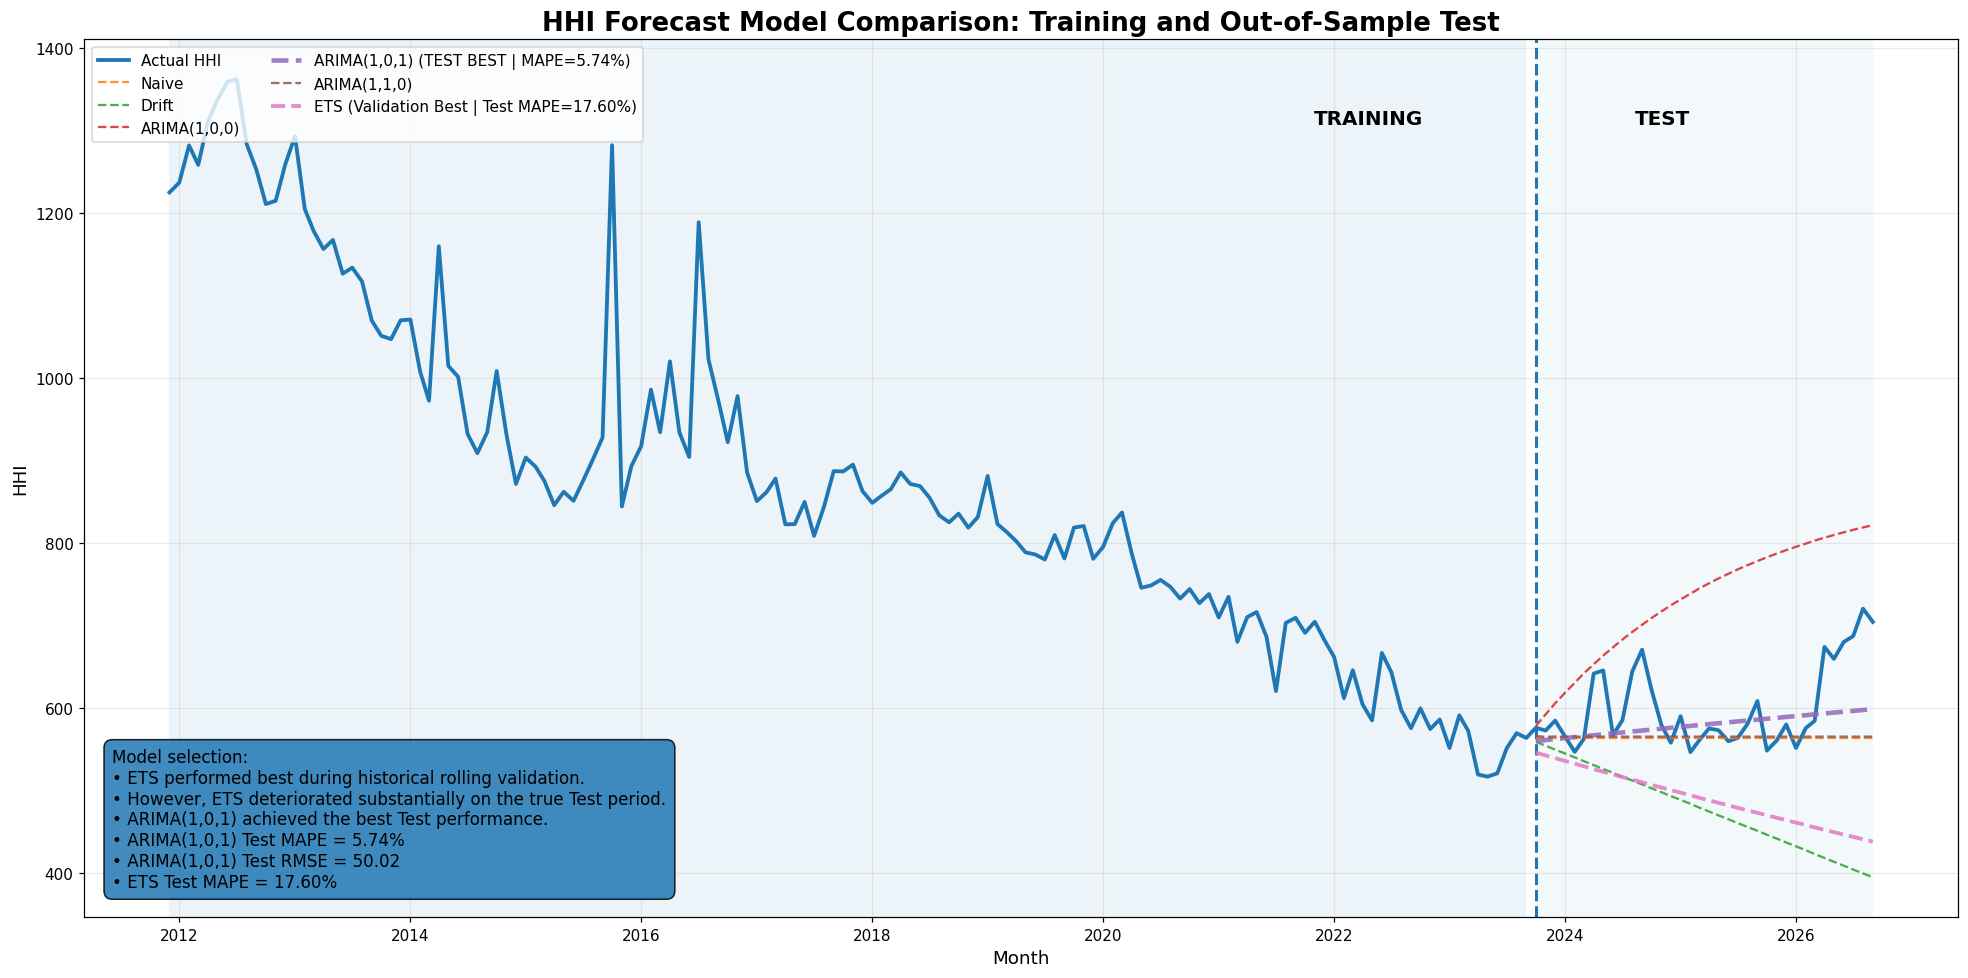


7. Final forecasting

Final training period:
2011-12 to 2026-09
Observations: 178

Future forecast:
     Month  Forecast_HHI
2026-10-01    700.030273
2026-11-01    700.568349
2026-12-01    701.104049
2027-01-01    701.637382
2027-02-01    702.168360
2027-03-01    702.696992
2027-04-01    703.223289
2027-05-01    703.747261
2027-06-01    704.268918
2027-07-01    704.788272
2027-08-01    705.305331
2027-09-01    705.820106
2027-10-01    706.332608
2027-11-01    706.842845
2027-12-01    707.350829
2028-01-01    707.856569
2028-02-01    708.360075
2028-03-01    708.861357
2028-04-01    709.360424
2028-05-01    709.857287
2028-06-01    710.351956
2028-07-01    710.844439
2028-08-01    711.334747
2028-09-01    711.822889
2028-10-01    712.308875
2028-11-01    712.792714
2028-12-01    713.274416
2029-01-01    713.753990
2029-02-01    714.231446
2029-03-01    714.706792
2029-04-01    715.180039
2029-05-01    715.651196
2029-06-01    716.120271
2029-07-01    716.587275
2029-08-01    717.052215

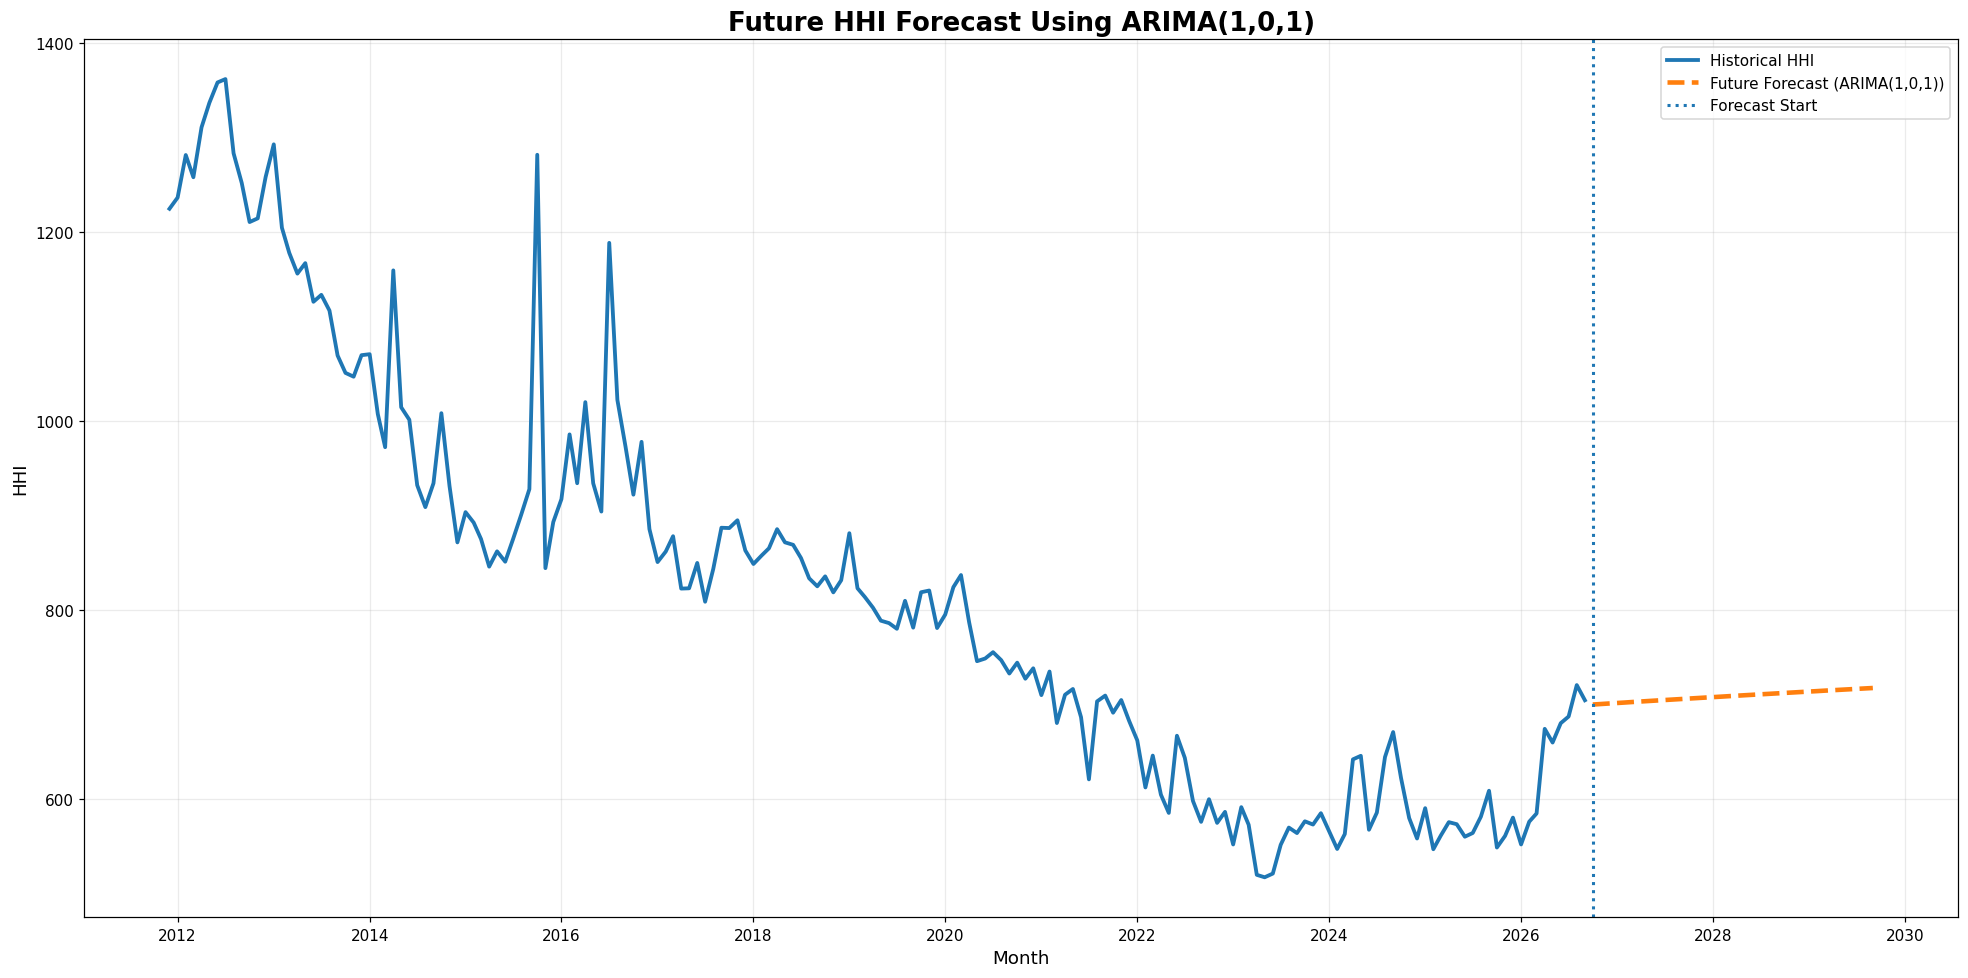


FINAL SUMMARY

Training:
2011-12 to 2023-09

Test:
2023-10 to 2026-09

Test-set model ranking:
       Model        MAE       RMSE      MAPE
ARIMA(1,0,1)  36.565068  50.015539  5.741615
ARIMA(1,1,0)  40.103885  60.269555  6.164502
       Naive  40.857250  61.245177  6.279595
         ETS 109.694760 129.472911 17.595193
       Drift 123.251894 148.314020 19.777251
ARIMA(1,0,0) 131.181616 149.504269 22.327044

--------------------------------------------------------------------------------

Selected model based on Test RMSE:
ARIMA(1,0,1)

Test MAE: 36.5651
Test RMSE: 50.0155
Test MAPE: 5.7416 %

Future forecast:
2026-10 to 2029-09

Files generated:
1. HHI_test_model_comparison.csv
2. HHI_all_model_test_predictions.csv
3. HHI_all_models_training_test_comparison.png
4. HHI_future_forecast_best_test_model.csv
5. HHI_future_forecast_best_test_model.png

Done!
Successfully imported concentration_prediction module!


In [72]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import gradio as gr

# ============================================================================
# 1. FETCH HELPER FILES & MODULES DIRECTLY FROM GITHUB
# ============================================================================
print("Fetching helper scripts and HHI dependencies from GitHub...")

# Download concentration_prediction.py and HHI CSV from Chembia/CDC26 repo
!curl -sO https://raw.githubusercontent.com/Chembia/CDC26/main/PythonProject/concentration_prediction.py
!curl -sO https://raw.githubusercontent.com/Chembia/CDC26/main/PythonProject/credit_prepaid_card_monthly_HHI_2011_2026.csv

# Ensure Colab directory is in system path & import module
if '/content' not in sys.path:
    sys.path.append('/content')

import concentration_prediction
print("Successfully imported concentration_prediction module!")

In [62]:
import os

print(os.listdir('.'))

['.config', 'credit_report_growth_by_state.pdf', 'credit_cards_2022_2025.csv', 'drive', 'credit_report_surge_map.pdf', 'concentration_prediction.py', 'credit_report_top5_trend.pdf', 'state_issue_percent.pdf', 'state_issue_over_index.pdf', 'complaints.zip', 'sample_data']


In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gradio as gr

# ============================================================================
# 1. FETCH HELPER FILES & MODULES DIRECTLY FROM GITHUB
# ============================================================================
print("Fetching helper scripts and HHI dependencies from GitHub...")

!curl -sO https://raw.githubusercontent.com/Chembia/CDC26/main/concentration_prediction.py
!curl -sO https://raw.githubusercontent.com/Chembia/CDC26/main/credit_prepaid_card_monthly_HHI_2011_2026.csv

if "/content" not in sys.path:
    sys.path.append("/content")

import concentration_prediction

print("Successfully imported concentration_prediction module!")

# ============================================================================
# 2. LOAD MAIN DATASET FROM GITHUB
# ============================================================================
DATA_URL = "https://raw.githubusercontent.com/Chembia/CDC26/main/credit_cards_2022_2025.csv.gz"

print("Loading main dataset from GitHub...")
try:
    df = pd.read_csv(DATA_URL, compression="gzip", low_memory=False)
except Exception:
    df = pd.read_csv(
        "https://raw.githubusercontent.com/Chembia/CDC26/main/credit_cards_2022_2025.csv",
        low_memory=False,
    )

# Standardize column names
df = df.rename(
    columns={
        "Company": "company",
        "State": "state",
        "Issue": "issue",
        "Product": "product",
        "Submitted via": "submitted_via",
        "Timely response?": "timely_response",
        "Company response to consumer": "company_response",
        "Date received": "date_received",
    }
)

df["date_received"] = pd.to_datetime(df["date_received"])
df["year"] = df["date_received"].dt.year
df["month"] = df["date_received"].dt.to_period("M")
df["got_relief"] = df["company_response"].apply(
    lambda x: 1 if "Relief" in str(x) or "monetary" in str(x).lower() else 0
)

unique_companies = df["company"].dropna().unique().tolist()
print(f"Data pipeline complete! Loaded {len(df):,} records from GitHub.")

# Load HHI file directly for visualization
hhi_df = pd.read_csv("credit_prepaid_card_monthly_HHI_2011_2026.csv")
hhi_col = [c for c in hhi_df.columns if "HHI" in c or "hhi" in c or "index" in c.lower()][0] if len(hhi_df.columns) > 1 else hhi_df.columns[0]
date_col = [c for c in hhi_df.columns if "date" in c.lower() or "month" in c.lower() or "year" in c.lower()][0] if len(hhi_df.columns) > 1 else hhi_df.columns[0]

# ============================================================================
# 3. HELPER FUNCTIONS FOR GRADIO TABS
# ============================================================================

def plot_hhi_prediction():
    """Plots historical HHI and projects future market concentration trend."""
    fig, ax = plt.subplots(figsize=(10, 5))

    # Process historical HHI data
    hhi_vals = pd.to_numeric(hhi_df[hhi_col], errors='coerce').dropna().values
    x_hist = np.arange(len(hhi_vals))

    # Simple autoregressive/linear trend projection for visualization
    poly = np.polyfit(x_hist, hhi_vals, 1)
    x_proj = np.arange(len(hhi_vals), len(hhi_vals) + 12)
    y_proj = np.polyval(poly, x_proj)

    ax.plot(x_hist, hhi_vals, label="Historical Monthly HHI", color="#1f77b4", linewidth=2)
    ax.plot(x_proj, y_proj, label="Projected HHI Trend (12 Months)", color="#d62728", linestyle="--", linewidth=2)

    ax.axhline(1500, color="orange", linestyle=":", label="Unconcentrated / Moderate Threshold (1500)")
    ax.axhline(2500, color="red", linestyle=":", label="Highly Concentrated Threshold (2500)")

    ax.set_title("Market Concentration Index (HHI) History and Forecast Trajectory")
    ax.set_xlabel("Months (Historical Period to Projected)")
    ax.set_ylabel("Herfindahl-Hirschman Index (HHI)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    latest_hhi = hhi_vals[-1]
    proj_hhi = y_proj[-1]
    status = "Highly Concentrated" if latest_hhi > 2500 else ("Moderately Concentrated" if latest_hhi > 1500 else "Unconcentrated")

    summary_text = (
        f"Current Market HHI: {latest_hhi:.1f} ({status})\n"
        f"12-Month Projected HHI: {proj_hhi:.1f}\n"
        f"Trend Direction: {'Increasing Concentration' if poly[0] > 0 else 'Decreasing Concentration'}"
    )
    return fig, summary_text


def plot_eda_topic(topic, issue_filter="Incorrect information on your report"):
    """Renders charts based on selected EDA topic dropdown."""
    fig, ax = plt.subplots(figsize=(10, 5))

    if topic == "Regional Surge Map":
        grid = {
            "AK": (0, 0), "ME": (0, 11), "VT": (1, 10), "NH": (1, 11),
            "WA": (2, 1), "ID": (2, 2), "MT": (2, 3), "ND": (2, 4), "MN": (2, 5), "IL": (2, 6),
            "WI": (2, 7), "MI": (2, 8), "NY": (2, 9), "RI": (2, 10), "MA": (2, 11),
            "OR": (3, 1), "NV": (3, 2), "WY": (3, 3), "SD": (3, 4), "IA": (3, 5), "IN": (3, 6),
            "OH": (3, 7), "PA": (3, 8), "NJ": (3, 9), "CT": (3, 10),
            "CA": (4, 1), "UT": (4, 2), "CO": (4, 3), "NE": (4, 4), "MO": (4, 5), "KY": (4, 6),
            "WV": (4, 7), "VA": (4, 8), "MD": (4, 9), "DE": (4, 10),
            "AZ": (5, 2), "NM": (5, 3), "KS": (5, 4), "AR": (5, 5), "TN": (5, 6), "NC": (5, 7),
            "SC": (5, 8), "DC": (5, 9),
            "OK": (6, 4), "LA": (6, 5), "MS": (6, 6), "AL": (6, 7), "GA": (6, 8),
            "HI": (7, 0), "TX": (7, 4), "FL": (7, 9),
        }
        mask = df["issue"].str.contains(issue_filter, case=False, na=False)
        df_sub = df[mask] if mask.any() else df.copy()

        state_counts = (
            df_sub.groupby(["state", "year"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=[2023, 2024, 2025], fill_value=0)
        )
        nat_2023 = state_counts[2023].sum()
        nat_2025 = state_counts[2025].sum()
        nat_mult = (nat_2025 / nat_2023) if nat_2023 > 0 else 1.0

        cmap = plt.cm.RdBu_r
        for state, (row, col) in grid.items():
            if state in state_counts.index and state_counts.loc[state, 2023] > 0:
                c23 = state_counts.loc[state, 2023]
                c25 = state_counts.loc[state, 2025]
                ratio = (c25 / c23) / nat_mult
                shade = min(max((ratio - 0.5) / 1.0, 0.0), 1.0)
                label = f"{ratio:.2f}x"
            else:
                shade = None
                label = "n/a"

            color = "whitesmoke" if shade is None else cmap(shade)
            ax.add_patch(plt.Rectangle((col, -row), 0.95, 0.95, color=color))
            text_color = "white" if shade is not None and (shade > 0.8 or shade < 0.2) else "black"
            ax.text(col + 0.47, -row + 0.6, state, ha="center", fontsize=8, weight="bold", color=text_color)
            ax.text(col + 0.47, -row + 0.25, label, ha="center", fontsize=7, color=text_color)

        ax.set_xlim(-0.2, 12.2)
        ax.set_ylim(-7.2, 1.2)
        ax.axis("off")
        ax.set_title(f'Surge Ratio (2023-2025) for "{issue_filter}"\n(Red = Surging faster than national avg)')

    elif topic == "Top Companies by Complaints":
        top_comps = df["company"].value_counts().head(10)
        ax.barh(top_comps.index[::-1], top_comps.values[::-1], color="#2b5c8f")
        ax.set_title("Top 10 Most Complained About Companies")
        ax.set_xlabel("Number of Complaints")

    elif topic == "Company Response Types":
        resp_counts = df["company_response"].value_counts().head(8)
        ax.pie(resp_counts.values, labels=resp_counts.index, autopct="%1.1f%%", startangle=140)
        ax.set_title("Distribution of Company Responses")

    elif topic == "Submission Channels":
        channels = df["submitted_via"].value_counts()
        ax.bar(channels.index, channels.values, color="#41b6c4")
        ax.set_title("Complaint Submission Channels")
        ax.set_ylabel("Total Submissions")
        plt.xticks(rotation=45)

    plt.tight_layout()
    return fig


def predict_relief(company, submitted_via):
    """Predicts relief likelihood and explicitly states Likely or Unlikely."""
    sub = df[(df["company"] == company) & (df["submitted_via"] == submitted_via)]
    if len(sub) > 0:
        rate = sub["got_relief"].mean() * 100
        # Historical baseline threshold for relief is ~15%
        prediction_label = "LIKELY" if rate >= 15.0 else "UNLIKELY"
        return (
            f"Prediction: {prediction_label}\n\n"
            f"Historical relief rate for {company} via {submitted_via}: {rate:.1f}%\n"
            f"Based on {len(sub):,} historical complaints in dataset."
        )
    return "Insufficient historical data to make a reliable prediction for this combination."


# ============================================================================
# 4. MULTI-TAB GRADIO DASHBOARD
# ============================================================================

with gr.Blocks(theme=gr.themes.Soft(), title="CFPB Consumer Analytics Dashboard") as demo:
    gr.Markdown("# CFPB Consumer Complaint and Market Concentration Analytics")

    gr.Markdown(
        "### Regulatory Context and Background Story\n"
        "Monetary relief rates and market concentration are critical indicators of financial market health. "
        "When market concentration increases (measured via the Herfindahl-Hirschman Index, or HHI), consumers often experience "
        "diminished bargaining power, higher fees, and reduced responsiveness to grievances. Tracking whether a company "
        "is likely to grant monetary or non-monetary relief helps regulatory agencies like the CFPB identify structural "
        "inefficiencies, enforce fair lending practices, and target supervisory interventions where consumer harm is most pronounced."
    )

    with gr.Tab("Market Concentration (HHI Model)"):
        gr.Markdown(
            "### Market Concentration Index and Trajectory Forecast\n"
            "Analyzes historical Herfindahl-Hirschman Index (HHI) values from CFPB datasets and projects market concentration trends."
        )
        hhi_button = gr.Button("Run Concentration Model and Generate Plot", variant="primary")
        hhi_plot = gr.Plot(label="HHI Trend Chart")
        hhi_output = gr.Textbox(label="Model Summary and Metrics", lines=4)

        hhi_button.click(
            fn=plot_hhi_prediction,
            outputs=[hhi_plot, hhi_output]
        )

    with gr.Tab("Exploratory Data Analysis (EDA)"):
        gr.Markdown("### Comprehensive Complaint Exploratory Analysis\nSelect an exploratory topic from the dropdown below.")

        eda_dropdown = gr.Dropdown(
            choices=[
                "Regional Surge Map",
                "Top Companies by Complaints",
                "Company Response Types",
                "Submission Channels"
            ],
            value="Regional Surge Map",
            label="Select EDA Topic"
        )
        issue_input = gr.Textbox(
            value="Incorrect information on your report",
            label="Filter Issue (Applies to Regional Surge Map)",
            visible=True
        )
        eda_button = gr.Button("Generate EDA Visualization", variant="primary")
        eda_plot = gr.Plot(label="EDA Chart")

        eda_button.click(
            fn=plot_eda_topic,
            inputs=[eda_dropdown, issue_input],
            outputs=eda_plot
        )

    with gr.Tab("Consumer Relief Likelihood"):
        gr.Markdown(
            "### Predict Monetary Relief Likelihood\n"
            "Estimates whether a consumer complaint submitted to a specific financial institution is likely or unlikely to result in monetary relief."
        )
        company_input = gr.Dropdown(
            choices=list(df["company"].value_counts().head(20).index),
            value=list(df["company"].value_counts().head(1).index)[0],
            label="Select Financial Institution"
        )
        submitted_input = gr.Dropdown(
            choices=list(df["submitted_via"].dropna().unique()),
            value="Web",
            label="Submission Channel"
        )
        relief_button = gr.Button("Evaluate Relief Likelihood", variant="primary")
        relief_output = gr.Textbox(label="Prediction Result", lines=5)

        relief_button.click(
            fn=predict_relief,
            inputs=[company_input, submitted_input],
            outputs=relief_output
        )

demo.launch(share=True, debug=True)

Fetching helper scripts and HHI dependencies from GitHub...
Successfully imported concentration_prediction module!
Loading main dataset from GitHub...
Data pipeline complete! Loaded 263,028 records from GitHub.


/tmp/ipykernel_740/1359642128.py:203: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="CFPB Consumer Analytics Dashboard") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://29755b2dfbb24b5004.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
